In [ ]:
%reset -f

In [ ]:
import pandas as pd

In [ ]:
LATITUDE = 51.08581600638418
LONGITUDE = -113.98369922856364

TIMEZONE = "America/Edmonton"

START_DATE = pd.to_datetime("2018-01-01 00:00:00").tz_localize(TIMEZONE)
END_DATE = pd.to_datetime("2023-02-06 23:00:00").tz_localize(TIMEZONE)

NOAA_MODEL = "ncep_gfs_seamless"

TILT=30
AZIMUTH=0

In [ ]:
df = pd.read_csv("Solar_Energy_Production.csv")
df['date'] = pd.to_datetime(df.date, format="%Y/%m/%d %I:%M:%S %p").dt.tz_localize(TIMEZONE, ambiguous='infer')

In [ ]:
from datetime import timezone
df = df[(df.name == "Whitehorn Multi-Service Centre") & (df.date > pd.to_datetime("2020", format="%Y").tz_localize(TIMEZONE))]

df = df.sort_values(by='date').reset_index(drop=True)

In [ ]:
full_range = pd.date_range(
    start=df['date'].min(), end=df['date'].max(), freq='h'
)

# 3. Find missing timestamps using difference
missing_dates = full_range.difference(df['date'])

# View missing timestamps as a DatetimeIndex
missing_series = pd.Series(missing_dates)

# Group continuous missing hours into gap blocks
gap_groups = (missing_series.diff() != pd.Timedelta(hours=1)).cumsum()
gap_summary = missing_series.groupby(gap_groups).agg(
    gap_start='min', gap_end='max', missing_hours='count'
)

print(gap_summary)

                     gap_start                   gap_end  missing_hours
1    2020-01-01 17:00:00-07:00 2020-01-02 08:00:00-07:00             16
2    2020-01-02 17:00:00-07:00 2020-01-03 07:00:00-07:00             15
3    2020-01-03 17:00:00-07:00 2020-01-04 07:00:00-07:00             15
4    2020-01-04 17:00:00-07:00 2020-01-05 07:00:00-07:00             15
5    2020-01-05 17:00:00-07:00 2020-01-06 07:00:00-07:00             15
...                        ...                       ...            ...
1152 2023-03-11 19:00:00-07:00 2023-03-12 07:00:00-06:00             12
1153 2023-03-12 20:00:00-06:00 2023-03-13 07:00:00-06:00             12
1154 2023-03-13 20:00:00-06:00 2023-03-14 07:00:00-06:00             12
1155 2023-03-14 20:00:00-06:00 2023-03-15 07:00:00-06:00             12
1156 2023-03-15 20:00:00-06:00 2023-03-16 06:00:00-06:00             11

[1156 rows x 3 columns]


<Axes: xlabel='date', ylabel='kWh'>

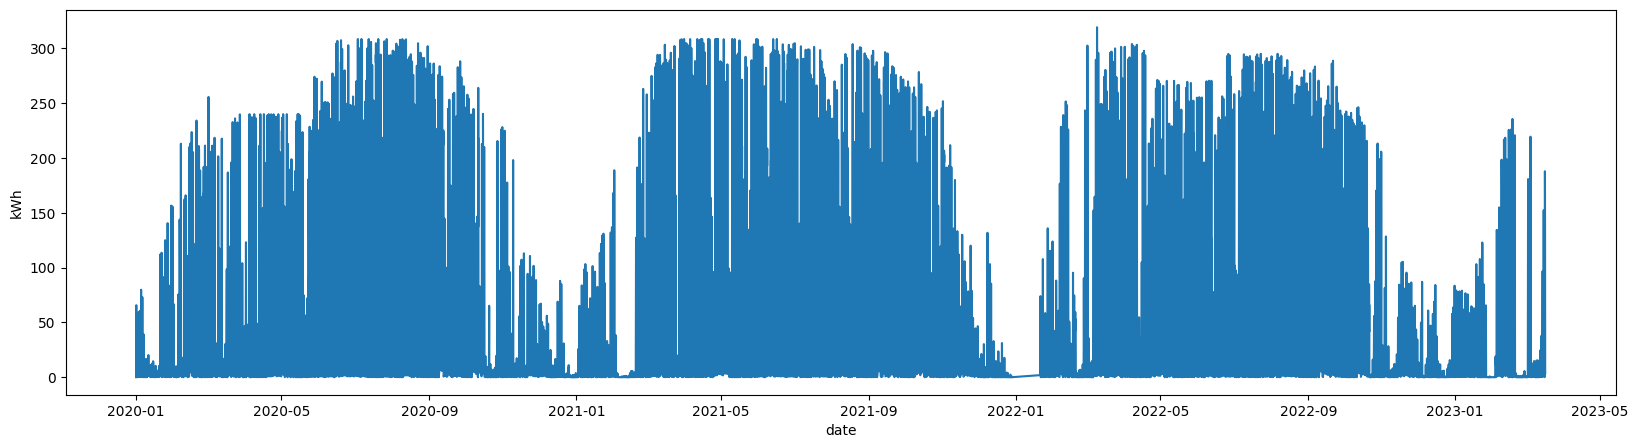

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))
import seaborn as sns
sns.lineplot(data=df, x='date', y='kWh')

In [ ]:
%%script true
import requests

url = (
    f"https://historical-forecast-api.open-meteo.com/v1/forecast?"
    f"latitude={LATITUDE}&longitude={LONGITUDE}&"
    f"start_hour={START_DATE.tz_convert('UTC').strftime("%Y-%m-%dT%H:%M")}&end_hour={END_DATE.tz_convert('UTC').strftime("%Y-%m-%dT%H:%M")}&"
    f"hourly=temperature_2m,cloud_cover,direct_radiation,diffuse_radiation,global_tilted_irradiance,weather_code,sunshine_duration,relative_humidity_2m,dewpoint_2m,wind_speed_10m,snow_depth,cloud_cover_low,cloud_cover_mid,cloud_cover_high&"
    f"models={NOAA_MODEL}&"
    f"tilt={TILT}&azimuth={AZIMUTH}&"
    f"timezone={TIMEZONE}"
)

response = requests.get(url).json()
weather_df = pd.DataFrame(response["hourly"])

weather_df["date"] = pd.to_datetime(weather_df["time"])
weather_df = weather_df.drop(columns=["time"])
weather_df['date'] = weather_df['date'].dt.tz_localize('UTC')

weather_df.to_csv("Whitehorn_weather_new.csv", index=False)

In [ ]:
weather_data_raw = pd.read_csv("Whitehorn_weather_new.csv")
weather_data = weather_data_raw.copy()
weather_data['date'] = pd.to_datetime(weather_data_raw['date']).dt.tz_convert(TIMEZONE)

In [ ]:
weather_data_1 = pd.read_csv("whitehorn1.csv")
weather_data_1['time'] = pd.to_datetime(weather_data_1['time'])
weather_data_2 = pd.read_csv("whitehorn2.csv")
weather_data_2['time'] = pd.to_datetime(weather_data_2['time'])
weather_data_3 = pd.read_csv("whitehorn3.csv")
weather_data_3['time'] = pd.to_datetime(weather_data_3['time'])

weather_data = weather_data_1.merge(right=weather_data_2, left_on='time', right_on='time')
weather_data = weather_data.merge(right=weather_data_3, left_on='time', right_on='time', how='left', suffixes=('', "_extra"))

weather_data = weather_data.rename(columns={
    'time': 'date'
})


weather_data['date'] = weather_data['date'].dt.tz_localize("UTC")
weather_data = weather_data.set_index('date')
weather_data = weather_data[(weather_data.index >= START_DATE)]

In [ ]:
weather_data

,temperature_2m (°C),weather_code (wmo code),pressure_msl (hPa),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation_probability (%),precipitation (mm),rain (mm),showers (mm),snowfall (cm),snow_depth (m),surface_pressure (hPa),cloud_cover (%),cloud_cover_mid (%),cloud_cover_low (%),cloud_cover_high (%),visibility (m),evapotranspiration (mm),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_speed_80m (km/h),wind_speed_100m (km/h),wind_speed_120m (km/h),wind_speed_180m (km/h),wind_speed_200m (km/h),wind_direction_10m (°),wind_direction_80m (°),wind_direction_100m (°),wind_direction_120m (°),wind_direction_180m (°),wind_direction_200m (°),wind_gusts_10m (km/h),temperature_80m (°C),temperature_120m (°C),temperature_180m (°C),soil_temperature_0cm (°C),soil_temperature_6cm (°C),soil_temperature_18cm (°C),soil_temperature_54cm (°C),soil_moisture_0_to_1cm (m³/m³),soil_moisture_1_to_3cm (m³/m³),soil_moisture_3_to_9cm (m³/m³),soil_moisture_9_to_27cm (m³/m³),soil_moisture_27_to_81cm (m³/m³),temperature_1000hPa (°C),temperature_975hPa (°C),temperature_925hPa (°C),temperature_950hPa (°C),temperature_900hPa (°C),temperature_850hPa (°C),temperature_800hPa (°C),temperature_700hPa (°C),temperature_600hPa (°C),temperature_500hPa (°C),temperature_400hPa (°C),temperature_300hPa (°C),temperature_250hPa (°C),temperature_200hPa (°C),temperature_150hPa (°C),temperature_100hPa (°C),temperature_70hPa (°C),temperature_50hPa (°C),temperature_30hPa (°C),uv_index (),uv_index_clear_sky (),sunshine_duration (s),is_day (),wet_bulb_temperature_2m (°C),total_column_integrated_water_vapour (kg/m²),cape (J/kg),lifted_index (),convective_inhibition (J/kg),freezing_level_height (m),boundary_layer_height (m),hail (undefined),shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²),direct_normal_irradiance (W/m²),global_tilted_irradiance (W/m²),terrestrial_radiation (W/m²),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²),global_tilted_irradiance_instant (W/m²),weather_code (wmo code)_extra,temperature_2m_max (°C),temperature_2m_min (°C),apparent_temperature_min (°C),apparent_temperature_max (°C),uv_index_max (),uv_index_clear_sky_max (),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),moonset (iso8601),shortwave_radiation_sum (MJ/m²),moon_phase (fraction),moonrise (iso8601),daylight_duration (s),sunshine_duration (s)_extra,sunset (iso8601),rain_sum (mm),showers_sum (mm),sunrise (iso8601),snowfall_sum (cm),precipitation_sum (mm),precipitation_hours (h),precipitation_probability_max (%),et0_fao_evapotranspiration (mm)_extra
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-01-01 07:00:00+00:00,-31.6,0.0,1031.7,61,-36.6,-36.9,NaN,0.0,0.0,0.0,0.0,0.86,886.3,0,0,0,0,14200.0,0.0,0.00,0.02,7.8,18.7,NaN,NaN,NaN,NaN,3,322,NaN,NaN,NaN,NaN,14.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,-31.6,NaN,0.0,40.6,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 08:00:00+00:00,-30.8,0.0,1031.8,60,-36.0,-36.1,NaN,0.0,0.0,0.0,0.0,0.86,886.8,0,0,0,0,12300.0,0.0,0.00,0.02,7.5,17.7,NaN,NaN,NaN,NaN,6,323,NaN,NaN,NaN,NaN,13.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,-30.8,NaN,0.0,40.3,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 09:00:00+00:00,-29.9,0.0,1031.4,60,-35.2,-35.3,NaN,0.0,0.0,0.0,0.0,0.86,886.9,0,0,0,0,12200.0,0.0,0.00,0.02,

In [ ]:
!pip install pvlib
import pvlib

times = pd.date_range(START_DATE, END_DATE, freq="h", tz=TIMEZONE)
times = times.tz_convert("UTC")
solpos = pvlib.solarposition.get_solarposition(times, LATITUDE, LONGITUDE)

aoi = pvlib.irradiance.aoi(
    surface_tilt=30,
    surface_azimuth=180,
    solar_zenith=solpos['zenith'],
    solar_azimuth=solpos['azimuth']
)

iam = pvlib.iam.physical(aoi)

gti = pvlib.irradiance.get_total_irradiance(
    surface_tilt=10,
    surface_azimuth=180,
    solar_zenith=solpos['zenith'],
    solar_azimuth=solpos['azimuth'],
    dhi=weather_data['diffuse_radiation_instant (W/m²)'],
    dni=weather_data['direct_normal_irradiance_instant (W/m²)'],
    ghi=weather_data['shortwave_radiation_instant (W/m²)'],
    albedo=0.3
)


cell_temp = pvlib.temperature.faiman(
    poa_global=gti['poa_global'],
    temp_air=weather_data['temperature_2m (°C)'],
    wind_speed=weather_data['wind_speed_10m (km/h)']
)


pvlib_data = pd.DataFrame ({
    'date': times.values,
    'elevation': solpos.elevation.values,
    'aoi': aoi.values,
    'iam': iam.values,
    'cell_temp': cell_temp.values,
    'gti': gti['poa_global']
})

pvlib_data['date'] = pvlib_data['date'].dt.tz_localize('UTC', ambiguous='infer').dt.tz_convert(TIMEZONE)

In [ ]:
full_range = pd.date_range(
    start=data['date'].min(), end=data['date'].max(), freq='h'
)

# 3. Find missing timestamps using difference
missing_dates = full_range.difference(data['date'])

# View missing timestamps as a DatetimeIndex
missing_series = pd.Series(missing_dates)

# Group continuous missing hours into gap blocks
gap_groups = (missing_series.diff() != pd.Timedelta(hours=1)).cumsum()
gap_summary = missing_series.groupby(gap_groups).agg(
    gap_start='min', gap_end='max', missing_hours='count'
)

print(gap_summary)

NameError: name 'data' is not defined

In [ ]:
%%script true
data = df.copy()
data = df.drop(columns=['name', 'id', 'address', 'public_url', 'installationDate', 'uid'])

data = data.merge(weather_data, on='date')
data = data.merge(pvlib_data, on='date')

data['weather_code'] = data['weather_code'].astype('category')
data = data.set_index('date')

data_merged = data.copy()
data


In [ ]:
!pip install darts[torch]

In [ ]:
%%script true

from darts.dataprocessing.transformers import MissingValuesFiller, Scaler
from darts import TimeSeries
from xgboost import XGBRegressor

data = data_post_proc1.copy()

FEATURES = data.columns.difference(['segment_id', 'is_long_gap', 'weather_code', 'kWh', 'hour', 'doy', 'month']).tolist()

split_idx = int(len(data) * 0.8)

data_train = data.iloc[:split_idx]
data_val = data.iloc[split_idx:]

fill_model = XGBRegressor(
    n_estimators=274,
    random_state=69420,
    learning_rate=0.016402891919412303,
    max_depth=8,
    subsample=0.6358289534884547,
    colsample_bytree=0.921776337426511,
    device='cuda',
    tree_method='hist'
  )

x = data_train[FEATURES]
y = data_train['kWh']

fill_model.fit(x, y)

continuous_hourly_index = pd.date_range(
    start=data_train.index.min(),
    end=data_train.index.max(),
    freq='h'
)

data_train = data_train.reindex(continuous_hourly_index)

data_train = data_train.reset_index(drop=False,)

data_train = data_train.merge(weather_data, left_on='index', right_on='date', suffixes=('_orig', ''))

data_train = data_train.merge(pvlib_data,  left_on='index', right_on='date', suffixes=('_orig2', ''))

cols_to_drop = [
    col
    for col in data_train.columns
    if col.endswith("_orig") or col.endswith("_orig2")
]

data_train = data_train.drop(columns=cols_to_drop)

data_train = data_train.set_index('index')

missing_mask = data_train['kWh'].isna()

x_missing = data_train.loc[missing_mask][data_train.columns.difference(['kWh', 'month', 'doy', 'hour', 'date', 'weather_code'])]

predicted_values = fill_model.predict(x_missing)

data_train.loc[missing_mask, 'kWh'] = predicted_values

data_train['hour'] = data_train.index.hour
data_train['month'] = data_train.index.month
data_train['doy'] = data_train.index.dayofyear

cols_to_drop = [ col for col in data_train.columns if col.startswith('wc_') ]

data_train = data_train.drop(columns=cols_to_drop)

data_train = pd.get_dummies(data_train, columns=['weather_code'], prefix='wc')
weather_code_cols = [col for col in data.columns if col.startswith('wc_')]
data_train[weather_code_cols] = data_train[weather_code_cols].astype(int)

data_train["hour_sin"] = np.sin(2 * np.pi * data_train["hour"] / 24.0)
data_train["hour_cos"] = np.cos(2 * np.pi * data_train["hour"] / 24.0)

data_train["month_sin"] = np.sin(2 * np.pi * (data_train["month"] - 1) / 12.0)
data_train["month_cos"] = np.cos(2 * np.pi * (data_train["month"] - 1) / 12.0)

data_train["doy_sin"] = np.sin(2 * np.pi * (data_train["doy"]) / 365.0)
data_train["doy_cos"] = np.cos(2 * np.pi * (data_train["doy"]) / 365.0)


In [ ]:
%%script true
continuous_hourly_index = pd.date_range(
    start=data_val.index.min(),
    end=data_val.index.max(),
    freq='h'
)

data_val = data_val.reindex(continuous_hourly_index)

data_val = data_val.reset_index(drop=False,)

data_val = data_val.merge(weather_data, left_on='index', right_on='date', suffixes=('_orig', ''))

data_val = data_val.merge(pvlib_data,  left_on='index', right_on='date', suffixes=('_orig2', ''))

cols_to_drop = [
    col
    for col in data_val.columns
    if col.endswith("_orig") or col.endswith("_orig2")
]

data_val = data_val.drop(columns=cols_to_drop)

data_val = data_val.set_index('index')

missing_mask = data_val['kWh'].isna()

x_missing = data_val.loc[missing_mask][data_val.columns.difference(['kWh', 'month', 'doy', 'hour', 'date', 'weather_code'])]

predicted_values = fill_model.predict(x_missing)

data_val.loc[missing_mask, 'kWh'] = predicted_values

data_val['hour'] = data_val.index.hour
data_val['month'] = data_val.index.month
data_val['doy'] = data_val.index.dayofyear

cols_to_drop = [ col for col in data_val.columns if col.startswith('wc_') ]

data_val = data_val.drop(columns=cols_to_drop)

data_val = pd.get_dummies(data_val, columns=['weather_code'], prefix='wc')
weather_code_cols = [col for col in data.columns if col.startswith('wc_')]
data_val[weather_code_cols] = data_val[weather_code_cols].astype(int)

data_val["hour_sin"] = np.sin(2 * np.pi * data_val["hour"] / 24.0)
data_val["hour_cos"] = np.cos(2 * np.pi * data_val["hour"] / 24.0)

data_val["month_sin"] = np.sin(2 * np.pi * (data_val["month"] - 1) / 12.0)
data_val["month_cos"] = np.cos(2 * np.pi * (data_val["month"] - 1) / 12.0)

data_val["doy_sin"] = np.sin(2 * np.pi * (data_val["doy"]) / 365.0)
data_val["doy_cos"] = np.cos(2 * np.pi * (data_val["doy"]) / 365.0)

In [ ]:
%%script true
data_train.index = data_train.index.tz_convert("UTC")
data_val.index = data_val.index.tz_convert("UTC")

target_train = TimeSeries.from_dataframe(
    data_train, value_cols=['kWh'], fill_missing_dates=True, freq='h'
)
target_val = TimeSeries.from_dataframe(
    data_val, value_cols=['kWh'], fill_missing_dates=True, freq='h'
)
covariates_train = TimeSeries.from_dataframe(
    data_train, value_cols=FEATURES, fill_missing_dates=True, freq='h'
)
covariates_val = TimeSeries.from_dataframe(
    data_val, value_cols=FEATURES, fill_missing_dates=True, freq='h'
)

target_scaler = Scaler()
covariates_scaler = Scaler()

target_train = target_scaler.fit_transform(target_train)
target_val = target_scaler.transform(target_val)

covariates_train = covariates_scaler.fit_transform(covariates_train)
covariates_val = covariates_scaler.transform(covariates_val)

covariates = covariates_train.concatenate(covariates_val)


In [ ]:
data = df.copy()
data = df.drop(columns=['name', 'id', 'address', 'public_url', 'installationDate', 'uid'])

weather_data_local = weather_data.copy()
weather_data_local.index = weather_data_local.index.tz_convert(TIMEZONE)

data = data.merge(weather_data, left_on='date', right_index=True, how='right')
data = data.merge(pvlib_data, on='date')

data = data.drop(
    columns = [
        'temperature_1000hPa (°C)',
        'temperature_975hPa (°C)',
        'temperature_925hPa (°C)',
        'temperature_950hPa (°C)',
        'temperature_900hPa (°C)',
        'temperature_850hPa (°C)',
        'temperature_800hPa (°C)',
        'temperature_700hPa (°C)',
        'temperature_600hPa (°C)',
        'temperature_500hPa (°C)',
        'temperature_400hPa (°C)',
        'temperature_300hPa (°C)',
        'temperature_250hPa (°C)',
        'temperature_200hPa (°C)',
        'temperature_150hPa (°C)',
        'temperature_100hPa (°C)',
        'temperature_70hPa (°C)',
        'temperature_50hPa (°C)',
        'temperature_30hPa (°C)',
        'total_column_integrated_water_vapour (kg/m²)',
        'boundary_layer_height (m)',
        'hail (undefined)',
        'precipitation_probability (%)',
        'precipitation_probability_max (%)',
        'showers (mm)',
        'weather_code (wmo code)',
        'precipitation (mm)',
        'evapotranspiration (mm)',
        'wind_speed_100m (km/h)',
        'wind_speed_120m (km/h)',
        'soil_moisture_9_to_27cm (m³/m³)',
        'cape (J/kg)',
        'convective_inhibition (J/kg)',
        'diffuse_radiation (W/m²)',
        'rain (mm)',
        'snowfall (cm)',
        'wind_direction_80m (°)',
        'wind_direction_100m (°)',
        'wind_direction_120m (°)',
        'wind_direction_180m (°)',
        'wind_direction_200m (°)',
        'wind_speed_180m (km/h)',
        'wind_speed_200m (km/h)',
        'temperature_80m (°C)',
        'temperature_120m (°C)',
        'temperature_180m (°C)',
        'soil_temperature_0cm (°C)',
        'soil_temperature_6cm (°C)',
        'soil_temperature_18cm (°C)',
        'soil_temperature_54cm (°C)',
        'soil_moisture_0_to_1cm (m³/m³)',
        'soil_moisture_1_to_3cm (m³/m³)',
        'soil_moisture_3_to_9cm (m³/m³)',
        'soil_moisture_27_to_81cm (m³/m³)',
        'sunrise (iso8601)',
        'moonrise (iso8601)',
        'sunset (iso8601)',
        'moonset (iso8601)',
        'showers_sum (mm)',
        'wind_direction_10m (°)',
        'shortwave_radiation (W/m²)',
        'direct_radiation (W/m²)',
        'direct_normal_irradiance (W/m²)',
        'global_tilted_irradiance (W/m²)',
        'terrestrial_radiation (W/m²)',
        'shortwave_radiation_instant (W/m²)',
        'direct_radiation_instant (W/m²)',
        'diffuse_radiation_instant (W/m²)',
        'direct_normal_irradiance_instant (W/m²)',
        'terrestrial_radiation_instant (W/m²)',
        'global_tilted_irradiance_instant (W/m²)',
        'uv_index_max ()',
        'uv_index_clear_sky_max ()',
        'wind_speed_10m_max (km/h)',
        'wind_gusts_10m_max (km/h)',
        'wind_direction_10m_dominant (°)',
        'shortwave_radiation_sum (MJ/m²)',
        'moon_phase (fraction)',
        # #'dew_point_2m (°C)',
        'apparent_temperature (°C)',
        'pressure_msl (hPa)',
        'cloud_cover_mid (%)',
        'cloud_cover_low (%)',
        'cloud_cover_high (%)',
        # #'et0_fao_evapotranspiration (mm)',
        # #'wet_bulb_temperature_2m (°C)',
        # 'wind_speed_10m (km/h)',
        # 'wind_gusts_10m (km/h)',
        # #'et0_fao_evapotranspiration (mm)_extra',
        # 'weather_code (wmo code)_extra',
        # 'temperature_2m_max (°C)',
        # 'temperature_2m_min (°C)',
        'apparent_temperature_min (°C)',
        'apparent_temperature_max (°C)',
        # #'lifted_index ()',
        # #'freezing_level_height (m)',
        #'daylight_duration (s)',
        #'sunshine_duration (s)_extra',
        'rain_sum (mm)',
        'precipitation_sum (mm)',
        'precipitation_hours (h)',
        'snowfall_sum (cm)'
    ]
)

data = data.interpolate(method='linear')

ffill_features = ['uv_index ()', 'uv_index_clear_sky ()']
for feature in ffill_features:
  data[feature] = data[feature].ffill()
  data[feature] = data[feature].bfill()

data.loc[(data['is_day ()'] == 0) & (data['kWh'].isna()), 'kWh'] = 0.0

data = data[(data['date'] > pd.to_datetime("2020").tz_localize('America/Edmonton'))]
data = data.dropna()

import pandas as pd
from scipy.stats import pearsonr
import numpy as np

target_series = data['kWh']

results = {}
for col in data.columns:
    if col == 'kWh' or col == 'date':
        continue

    corr, p_value = pearsonr(data[col], target_series)
    results[col] = {
        'correlation': corr,
        'p_value': p_value
    }

# Convert results into a clean DataFrame for viewing
result_df = pd.DataFrame(results).T
result_df
#print(result_df[(result_df['p_value'].abs() > 0.05)])

,correlation,p_value
temperature_2m (°C),0.466973,0.000000e+00
relative_humidity_2m (%),-0.348993,0.000000e+00
dew_point_2m (°C),0.328473,0.000000e+00
snow_depth (m),-0.121582,4.956944e-90
surface_pressure (hPa),0.273521,0.000000e+00
cloud_cover (%),-0.193209,6.934109e-227
visibility (m),0.357788,0.000000e+00
et0_fao_evapotranspiration (mm),0.815717,0.000000e+00
vapour_pressure_deficit (kPa),0.516150,0.000000e+00
wind_speed_10m (km/h),0.160516,2.541748e-156


In [ ]:
data['date'] = data['date'].dt.tz_convert('UTC')
data = data.set_index('date')

In [ ]:
import numpy as np
data['hour'] = data.index.hour
data['month'] = data.index.month
data['doy'] = data.index.dayofyear

data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24.0)
data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24.0)

data["month_sin"] = np.sin(2 * np.pi * (data["month"] - 1) / 12.0)
data["month_cos"] = np.cos(2 * np.pi * (data["month"] - 1) / 12.0)

data["doy_sin"] = np.sin(2 * np.pi * (data["doy"]) / 365.0)
data["doy_cos"] = np.cos(2 * np.pi * (data["doy"]) / 365.0)

data_post_proc1 = data.copy()

In [ ]:
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler

target = TimeSeries.from_dataframe(
    data, value_cols=['kWh'], fill_missing_dates=True, freq='h'
)

covariates = TimeSeries.from_dataframe(
    data, value_cols=data.columns.difference(['kWh']).tolist(), fill_missing_dates=True, freq='h'
)


target_train, target_val = target.split_after(0.8)
covariates_train, covariates_val = covariates.split_after(0.8)

target_scaler = Scaler()
covariates_scaler = Scaler()

target_train = target_scaler.fit_transform(target_train)
target_val = target_scaler.transform(target_val)

covariates_train = covariates_scaler.fit_transform(covariates_train)
covariates_val = covariates_scaler.transform(covariates_val)

covariates = covariates_train.concatenate(covariates_val)


In [ ]:
from darts.models import XGBModel
model = XGBModel(
    lags=24,
    lags_future_covariates=(24,24),
    output_chunk_length=24,
    n_estimators=274, random_state=69420, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511,
    tree_method = "hist",
    multi_models=False,
    device = 'cuda',
    kwargs={
        "tree_method": "hist",
        "device": "cuda"
    }
)


model.fit(
    series=target_train,
    future_covariates=covariates,
    val_series=target_val,
    val_future_covariates=covariates,
)

[0]	validation_0-rmse:0.23396
[1]	validation_0-rmse:0.23048
[2]	validation_0-rmse:0.22705
[3]	validation_0-rmse:0.22371
[4]	validation_0-rmse:0.22043
[5]	validation_0-rmse:0.21721
[6]	validation_0-rmse:0.21403
[7]	validation_0-rmse:0.21081
[8]	validation_0-rmse:0.20775
[9]	validation_0-rmse:0.20468
[10]	validation_0-rmse:0.20170
[11]	validation_0-rmse:0.19876
[12]	validation_0-rmse:0.19584
[13]	validation_0-rmse:0.19301
[14]	validation_0-rmse:0.19024
[15]	validation_0-rmse:0.18755
[16]	validation_0-rmse:0.18486
[17]	validation_0-rmse:0.18221
[18]	validation_0-rmse:0.17960
[19]	validation_0-rmse:0.17711
[20]	validation_0-rmse:0.17460
[21]	validation_0-rmse:0.17214
[22]	validation_0-rmse:0.16966
[23]	validation_0-rmse:0.16724
[24]	validation_0-rmse:0.16493
[25]	validation_0-rmse:0.16258
[26]	validation_0-rmse:0.16033
[27]	validation_0-rmse:0.15807
[28]	validation_0-rmse:0.15588
[29]	validation_0-rmse:0.15371
[30]	validation_0-rmse:0.15162
[31]	validation_0-rmse:0.14957
[32]	validation_0-

XGBModel(lags=24, lags_past_covariates=None, lags_future_covariates=(24, 24), output_chunk_length=24, output_chunk_shift=0, add_encoders=None, likelihood=None, quantiles=None, random_state=69420, multi_models=False, use_static_covariates=True, n_estimators=274, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511, tree_method=hist, device=cuda, kwargs={'tree_method': 'hist', 'device': 'cuda'})

In [ ]:
import numpy as np
from darts import metrics
full_target = target_train.concatenate(target_val)

forecast_24h_ahead = model.historical_forecasts(
    series=full_target,
    future_covariates=covariates,
    start=target_val.start_time(),
    forecast_horizon=24,
    stride=1,
    last_points_only=True,
    retrain=False,
    verbose=True,
)


forecast_24h_ahead = forecast_24h_ahead.map(lambda x: np.maximum(0, x))

actual_24h_ahead = full_target.slice_intersect(forecast_24h_ahead)

#forecast_24h_ahead = target_scaler.inverse_transform(forecast_24h_ahead)

#actual_24h_ahead = target_scaler.inverse_transform(forecast_24h_ahead)

rmse = metrics.rmse(actual_24h_ahead, forecast_24h_ahead)
mae = metrics.mae(actual_24h_ahead, forecast_24h_ahead)
r2 = metrics.r2_score(actual_24h_ahead, forecast_24h_ahead)

print("=== 24-Hour Lead Time Evaluation (last_points_only=True) ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")


historical forecasts: 100%|██████████| 1/1 [00:00<00:00, 15.67it/s]

=== 24-Hour Lead Time Evaluation (last_points_only=True) ===
RMSE : 0.0603
MAE  : 0.0275
R2   : 0.9357


In [ ]:
start_time = pd.Timestamp("2022-7-3 00:00:00").tz_localize(TIMEZONE).tz_convert('utc').tz_localize(None) # Objectively fried time tomfoolery
end_time = pd.Timestamp("2022-7-7 23:00:00").tz_localize(TIMEZONE).tz_convert('utc').tz_localize(None)

full_series = target_train.concatenate(target_val)

historical_context = full_series[:start_time]

# 6. Predict
forecast_scaled = model.predict(
    n=24*5,
    series=historical_context,
    future_covariates=covariates,
)

forecast = target_scaler.inverse_transform(forecast_scaled)

forecast = forecast.map(lambda x: np.maximum(0, x))

<Figure size 1200x600 with 0 Axes>

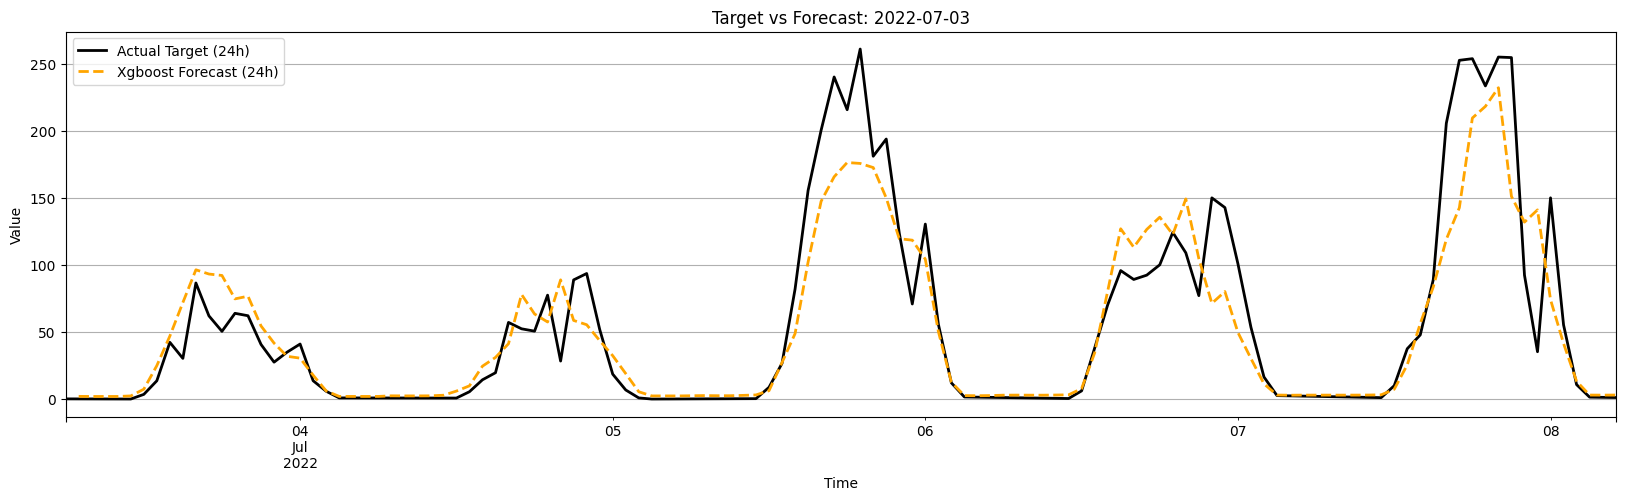

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

actual_24h = full_series.slice(start_time, end_time)
forecast_24h = forecast.slice(start_time, end_time)

actual_24h = target_scaler.inverse_transform(actual_24h)

plt.figure(figsize=(20, 5))
actual_24h.plot(label="Actual Target (24h)", color="black", linewidth=2)

forecast_24h.plot(
    label="Xgboost Forecast (24h)", color="orange", linestyle="--", linewidth=2
)

plt.title(f"Target vs Forecast: {start_time.date()}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from darts.dataprocessing.transformers import Diff

differencer = Diff()
target_stationary = differencer.fit_transform(full_target)
target_val_stationary = differencer.transform(target_val)

In [ ]:
#%%script true
from darts.explainability import ShapExplainer

target_time = pd.Timestamp("2022-09-20 00:00:00").tz_localize(TIMEZONE).tz_convert('utc').tz_localize(None)

#start_window = target_time - pd.Timedelta(days=1)
#end_window = target_time + pd.Timedelta(days=1)

#target_stationary = target_stationary[start_window : end_window]


explainer = ShapExplainer(
    model=model,
    background_series=target_stationary,
    background_future_covariates=covariates,
)

shap_result = explainer.explain(
    foreground_series=target_stationary,
    foreground_future_covariates=covariates,
)

In [ ]:
#%%script true
# Plot summary across features
plt.figure(figsize=(10, 6))
explainer.summary_plot()
plt.title("Darts ShapExplainer - Feature Importances")
plt.tight_layout()
plt.show()